In [28]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

**<font size="6" color="red">ch01. 허깅페이스 모델 사용</form>**
- Inference API 이용 : 모델의 결과를 server에서
- pipeline() 이용 : 모델을 다운로드 받아 모델의 결과를 local에서
```
허깅페이스 transformer에서 지원하는 task
text-classification : (별칭 sentiment-analysis)	감정 분석, 뉴스 분류, 리뷰 분류 등 문장 분류
zero-shot-classification	: 레이블에 대한 별도 학습 없이 후보 레이블 중에서 분류
text-generation	: GPT 계열 모델을 이용한 텍스트 생성
fill-mask	: 문장 안의 빈칸(마스크)에 들어갈 단어 예측
ner (token-classification의 별칭)	: 개체명 인식(사람, 조직, 장소 등 라벨링)
question-answering	: 주어진 지문(context)을 근거로 질문에 답변
summarization	: 긴 문서를 짧게 요약
translation	: 서로 다른 언어 간 번역
image-to-text	: 이미지 내용을 설명하는 문장 생성
image-classification	: 이미지가 어떤 대상인지 분류

```

In [2]:
import warnings
import os
import logging
 
# 경고 메시지 제거
warnings.filterwarnings('ignore')
 
# transformers 라이브러리의 로깅 레벨을 ERROR로 조정 (경고 숨김)
logging.getLogger("transformers").setLevel(logging.ERROR)
 
# Hugging Face 캐시 관련 symlink 경고 제거
# os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. 텍스트 기반 감정분석(긍정 / 부정)
- 토큰화 -> 워드임베딩 -> 모델 -> predict : pipeline()함수는 이 단계를 내부적으로 해 줌

In [3]:
from transformers import pipeline
classifier = pipeline(task="text-classification",
                     model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
classifier("I've been waiting for a Hugging face course my whole life.")

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9982948899269104}]

In [3]:
# 특정 모델의 파라미터와 용량
from transformers import AutoModel

model = AutoModel.from_pretrained("distilbert/distilbert-base-uncased-finetuned-sst-2-english")

# 전체 파라미터 개수 세기
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 수: {total_params/1024/1024:.3f}MB")

In [4]:
from transformers import pipeline
classifier = pipeline(task="sentiment-analysis",
                     model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")
# 감정분석할 내용이 많으면 list
classifier([
    "I've been waiting for a Hugging face course my whole life.",
    "I hate this so much!"
])

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9982948899269104},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

In [10]:
classifier("이 영화 정말 최고였어요. 감동적이고 연기도 대단해요!")

[{'label': 'POSITIVE', 'score': 0.975276529788971}]

In [13]:
classifier(["I like you", "I hate you", "힘들어요"])

[{'label': 'POSITIVE', 'score': 0.9998695850372314},
 {'label': 'NEGATIVE', 'score': 0.9991129040718079},
 {'label': 'POSITIVE', 'score': 0.8669533729553223}]

In [14]:
classifier = pipeline(task="sentiment-analysis",
                     model="daekeun-ml/koelectra-small-v3-nsmc")
texts = ['힘들어요',"오늘 기분이 최고야", "당신이 싫어요", "난 네가 참 좋아"]
classifier(texts)

Device set to use cpu


[{'label': '0', 'score': 0.9957089424133301},
 {'label': '1', 'score': 0.9943759441375732},
 {'label': '0', 'score': 0.9989749193191528},
 {'label': '1', 'score': 0.5141964554786682}]

In [15]:
for text, result in zip(texts, classifier(texts)):
    label = "긍정" if result['label']=='1' else "부정"
    print(f"'{text}' -> {label} {result['score']:.2%}")

'힘들어요' -> 부정 99.57%
'최고' -> 긍정 99.44%
'싫어요' -> 부정 99.90%
'너가 좋아' -> 긍정 51.42%


# 2. 제로샷(Zero-shot-분류)
- 제로샷 분류는 기계학습 및 자연어 처리에서 개별 작업에 대한 별도의 학습(파인튜닝) 없이도 분류 작업을 수행할 수 있는 방식이다. 분류하고자 하는 후보 레이블(candidate_labels)만 지정해 주면, 모델이 사전에 학습한 언어 지식을 바탕으로 입력 문장이 어떤 레이블에 가장 가까운지 확률로 계산해 준다

In [3]:
from transformers import pipeline
classifier = pipeline(task='zero-shot-classification',
                     model='facebook/bart-large-mnli')
classifier("I have a probloem with my iphone that needs to be resolved asap!!",
        candidate_labels=['phone', 'urgent','tablet', 'computer'])

Device set to use cpu


{'sequence': 'I have a probloem with my iphone that needs to be resolved asap!!',
 'labels': ['urgent', 'phone', 'computer', 'tablet'],
 'scores': [0.5075381398200989,
  0.4736008942127228,
  0.016089128330349922,
  0.0027717777993530035]}

In [4]:
classifier("This is a course about the Tranformers library.",
          candidate_labels=["education", "business", "phone"])

{'sequence': 'This is a course about the Tranformers library.',
 'labels': ['education', 'business', 'phone'],
 'scores': [0.8320797681808472, 0.09927219897508621, 0.06864806264638901]}

# 3. text 생성
- gpt2 : 파라미터갯수 124,439,808개
- 모델 용량 : 124,439,808 * 4 => 118.675MB
- finetuning시 추가메모리 : 학습시 활성화함수, 옵티마이저, 미분 등으로 4배 정도 메모리 필요

In [6]:
from transformers import AutoModel

model = AutoModel.from_pretrained("gpt2")

# 전체 파라미터 개수 세기
total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")
print(f"전체 파라미터 수: {total_params/1024/1024:.3f}MB")

전체 파라미터 수: 124,439,808
전체 파라미터 수: 118.675MB


In [9]:
generator = pipeline(task="text-generation",
                     model="gpt2")
generator("In this course. We will teach you how to",
          pad_token_id=generator.tokenizer.eos_token_id)

Device set to use cpu


[{'generated_text': 'In this course. We will teach you how to use the language of the book to learn it. You will also learn how to use it in your own personal projects, and how to use it as a tool to help you learn more about the world you are a part of.\n\nHow to develop a language. This course will show you how to develop a language so you will have a foundation for getting started with using it. You will also learn about the various ways in which you can develop your own language for the purpose of learning it.\n\nHow to use the language of the book. This course will show you how to use the language of the book to learn it. You will also learn about the various ways in which you can use it in your own personal projects, and how to use it as a tool to help you learn more about the world you are a part of.\n\nHow to use the language of the book to learn it. This course will show you how to use the language of the book to learn it. You will also learn about the various ways in which yo

In [10]:
result = generator("In this course. We will teach you how to",
          pad_token_id=generator.tokenizer.eos_token_id)
print(result[0]['generated_text'])

In this course. We will teach you how to use the following tools to customize your own web application:

Create an account on Github (this is what we did).

Create a project file (this is what we did).

Create a blog (this is what we did).

Create a new project on GitHub (this is what we did).

Create a project on GitHub (this is what we did). Create a new project on GitHub (this is what we did).

Create an account on Github.

Create a project on GitHub. Create an account on Github. Create a project on GitHub. Create a project on GitHub. Create a project on GitHub. Create a project on GitHub. Create a project on GitHub. Create a project on GitHub.

Create and add a new project on GitHub.

Create a new project on GitHub. Create a new project on Github. Create a project on GitHub. Create a project on GitHub. Create a project on GitHub. Create a project on GitHub. Create a project on GitHub. Create a project on GitHub. Create a project on GitHub. Create a project on GitHub. Create a proje

In [15]:
generator = pipeline("text-generation", "skt/kogpt2-base-v2", 
                     device=-1) # GPU사용시 0입력
prompt = "이 과정은 다음과 같은 것을 알려드려요."
result = generator(prompt,
                   pad_token_id=generator.tokenizer.eos_token_id,
                   max_new_tokens=20,
                   do_sample=True,        # 샘플링 사용
                   top_k = 50,            # 토큰 후보 폭을 다양하게 확보
                   temperature=0.8,       # 0.2는 너무 보수적, 0.9정도는 유연한 대답
                   top_p = 0.9,           # 상위 90% 누적 확률 토큰만
                   repetition_penalty=1.2 # 반복적인 단어는 패널티를  
                   )  
print(result[0]['generated_text'])

Device set to use cpu


이 과정은 다음과 같은 것을 알려드려요."
"우리가 그걸 할 수 있는 건, 우리가 우리를 어떻게 다루느냐에 달려 있다는 것이


# 4. 마스크 채우기

In [18]:
unmasker = pipeline(task="fill-mask",
                   model="distilbert/distilroberta-base") # 마스크 채우기
unmasker("I'm going to hospital and meet a <mask>", top_k=2)

Some weights of the model checkpoint at distilbert/distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.19275707006454468,
  'token': 3299,
  'token_str': ' doctor',
  'sequence': "I'm going to hospital and meet a doctor"},
 {'score': 0.06794589757919312,
  'token': 27321,
  'token_str': ' psychiatrist',
  'sequence': "I'm going to hospital and meet a psychiatrist"}]

In [ ]:
# unmasker = pipeline("fill-mask", )
# unmasker("Hello, I'm a [MASK] model.")

## inference API 이용
- 모델의 결과를 server에게

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()
print(os.getenv('HF_TOKEN')[:2])

hf


In [9]:
from huggingface_hub import InferenceClient
client = InferenceClient(
    provider='hf-inference',
    api_key=os.getenv('HF_TOKEN')
)
result = client.fill_mask("Hello, I'm a [MASK] model.",
                    model="google-bert/bert-base-uncased")
result

[FillMaskOutputElement(score=0.1441427320241928, sequence="hello, i ' m a role model.", token=2535, token_str='role', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.14175812900066376, sequence="hello, i ' m a fashion model.", token=4827, token_str='fashion', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.06221463158726692, sequence="hello, i ' m a new model.", token=2047, token_str='new', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.04102848470211029, sequence="hello, i ' m a super model.", token=3565, token_str='super', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.02591117098927498, sequence="hello, i ' m a business model.", token=2449, token_str='business', fill_mask_output_token_str=None)]

In [10]:
[r.sequence for r in result]

["hello, i ' m a role model.",
 "hello, i ' m a fashion model.",
 "hello, i ' m a new model.",
 "hello, i ' m a super model.",
 "hello, i ' m a business model."]

In [11]:
# 다국어 지언되는 mask 모델
from transformers import pipeline
unmasker = pipeline("fill-mask", "google-bert/bert-base-uncased")
unmasker("안녕하세요. 나는[MASK] 모델입니다", top_k=3)

Some weights of the model checkpoint at google-bert/bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.43014705181121826,
  'token': 100,
  'token_str': '[UNK]',
  'sequence': '안녕하세요. 나는 모델입니다'},
 {'score': 0.1528875082731247,
  'token': 1012,
  'token_str': '.',
  'sequence': '안녕하세요. 나는. 모델입니다'},
 {'score': 0.12364356964826584,
  'token': 1024,
  'token_str': ':',
  'sequence': '안녕하세요. 나는 : 모델입니다'}]

In [12]:
[r['sequence'] for r in result]

["hello, i ' m a role model.",
 "hello, i ' m a fashion model.",
 "hello, i ' m a new model.",
 "hello, i ' m a super model.",
 "hello, i ' m a business model."]

# 5. 개체명 인식(NER ; Named Entity Recoggnition)

In [13]:
ner = pipeline("ner", "dbmdz/bert-large-cased-finetuned-conll03-english",
               grouped_entities=True) # 객체들을 그룸브오 묶을지 말지
ner("My name is Sylvain and I work at Hugging Face in Brooklyn.")

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
C:\Users\mbc1\anaconda3\envs\llm\lib\site-packages\transformers\pipelines\token_classification.py:186: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="simple"` instead.
  warnings.warn(


[{'entity_group': 'PER',
  'score': np.float32(0.9981694),
  'word': 'Sylvain',
  'start': 11,
  'end': 18},
 {'entity_group': 'ORG',
  'score': np.float32(0.9796019),
  'word': 'Hugging Face',
  'start': 33,
  'end': 45},
 {'entity_group': 'LOC',
  'score': np.float32(0.9932106),
  'word': 'Brooklyn',
  'start': 49,
  'end': 57}]

# 6. 질의응답
- context에 대한 질의 응답

In [15]:
question_answer = pipeline("question-answering")
question_answer(
    question="Where do I work",
    context="My name is Sylvain and I work at Hugging Face in Brooklyn."
)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


{'score': 0.6033822298049927, 'start': 33, 'end': 45, 'answer': 'Hugging Face'}

In [16]:
context = "My name is Sylvain and I work at Hugging Face in Brooklyn."
context[33:45]

'Hugging Face'

# 7. 문서요약
- torch 버전 2.6보다 낮으면 문서요약 안 될 수 있음

In [17]:
summarizer = pipeline("summarization",
                      "facebook/bart-large-cnn")
summarizer('''
At a product launch event held on the 9th (local time) at Apple Park in Cupertino, California, Apple unveiled its first foldable smartphone, the “iPhone Duo.”

Korea is included among the first-wave launch countries, and pre-orders will be available starting October 16, with official sales beginning on the 23rd of next month.

The iPhone Duo is designed to open left and right like a book, and when folded, it resembles a passport
''',
        max_length=130,
          min_length=30,
          do_sample=True)

Device set to use cpu
Your max_length is set to 130, but your input_length is only 106. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=53)


[{'summary_text': 'The iPhone Duo is designed to open left and right like a book, and when folded, it resembles a passport. pre-orders will be available starting October 16, with official sales beginning on the 23rd of next month.'}]

# 8. 번역

In [18]:
# pip install sacremoses
translator = pipeline('translation',
                      'Helsinki-NLP/opus-mt-fr-en') # 프랑스어 -> 영어

Device set to use cpu


In [19]:
translator('Ce cours est produit par Hugging Face')

[{'translation_text': 'This course is produced by Hugging Face'}]

In [21]:
# 한 -> 영
ko2en = pipeline("translation", model="Helsinki-NLP/opus-mt-ko-en")
# 영 -> 한(불량)
en2ko = pipeline("translation", model="Helsinki-NLP/opus-mt-tc-big-en-ko")
# 테스트 문장
ko_sentence = "이 문장을 영어로 번역해 주세요"
en_sentence = "I enjoy learning about AI"
# 번역
print('한 -> 영 : ', ko2en(ko_sentence)[0]['translation_text'])
print('영 -> 한 : ', en2ko(en_sentence)[0]['translation_text'])

Device set to use cpu
Device set to use cpu


한 -> 영 :  Please translate this sentence into English.
영 -> 한 :  US  풍선 행


In [23]:
result = ko2en([
    '안녕하세요? 즐거운 하루 보내세요',
    '내일부터는 open ai API를 나갑니다',
    '결제를 위해서 직불카드 지참바랍니다'
])
[r['translation_text'] for r in result]

['Hello? Have a good day.',
 'Tomorrow, we go to the Open ai APl.',
 "I hope you don't have a direct card for the payment."]

# 9. 이미지를 설명하는 텍스트


In [ ]:
url = 'https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png'
from PIL import Image
import requests
import numpy as np
response = requests.get(url, stream=True).raw
image = Image.open(response)
# image = image.resize((150,150))
image_npy = np.array(image)
print(type(image_npy), image_npy.shape)
import matplotlib.pyplot as plt
plt.imshow(image_npy, cmap='gray')

In [ ]:
from transformers import pipeline
imagetotext = pipeline("image-to-text",
                      "ydshieh/vit-gpt2-coco-en")
imagetotext(url, max_new_tokens=30) # 30토큰 내로 설명

In [ ]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
response = requests.get(url, stream=True).raw
image = Image.open(response)
imagetotext(url, max_new_tokens=50)

In [ ]:
filename = 'images/fb.jpg'
# Image.open(filename) : 파일 내용
imagetotext(filename, max_new_tokens=50)

# 10. 이미지분류

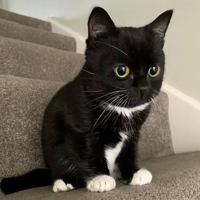

In [27]:
image = Image.open('images/cat.jpg')
image.resize((200,200))

In [ ]:
imgclassifier = pipeline("image-classification",
                        "google/vit-base-patch16-224")
imgclassifier(image)